# Final EDA Mini Project

## Scenario
#### You are a Junior Data Scientist working for an HR Analytics company.
#### The company wants to understand:
#### Why employees leave
#### What affects salary
#### Whether experience affects performance
#### Which department performs best
#### Whether overtime affects attrition
#### Which factors are correlated

In [147]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

n = 100

df = pd.DataFrame({
    'Employee_ID': range(1, n+1),
    'Age': np.random.randint(22, 60, n),
    'Experience': np.random.randint(1, 35, n),
    'Department': np.random.choice(
        ['IT', 'HR', 'Finance', 'Sales'],
        n
    ),
    'Salary': np.random.randint(
        25000, 120000, n
    ),
    'Performance_Score': np.random.randint(
        50, 100, n
    ),
    'Overtime': np.random.choice(
        ['Yes', 'No'],
        n
    ),
    'Attrition': np.random.choice(
        ['Yes', 'No'],
        n
    )
})

# Add some missing values

df.loc[5, 'Salary'] = np.nan
df.loc[10, 'Experience'] = np.nan
df.loc[20, 'Performance_Score'] = np.nan

df.head()

,Employee_ID,Age,Experience,Department,Salary,Performance_Score,Overtime,Attrition
0,1,50,1.0,Sales,65764.0,91.0,Yes,Yes
1,2,36,14.0,Sales,99543.0,79.0,No,No
2,3,29,3.0,HR,70714.0,68.0,No,Yes
3,4,42,1.0,Sales,81835.0,66.0,Yes,No
4,5,40,5.0,IT,98744.0,68.0,No,Yes


## Data Understanding

In [148]:
hr_data = df.copy()
hr_data.head(5)

,Employee_ID,Age,Experience,Department,Salary,Performance_Score,Overtime,Attrition
0,1,50,1.0,Sales,65764.0,91.0,Yes,Yes
1,2,36,14.0,Sales,99543.0,79.0,No,No
2,3,29,3.0,HR,70714.0,68.0,No,Yes
3,4,42,1.0,Sales,81835.0,66.0,Yes,No
4,5,40,5.0,IT,98744.0,68.0,No,Yes


In [149]:
hr_data.tail(5)

,Employee_ID,Age,Experience,Department,Salary,Performance_Score,Overtime,Attrition
95,96,58,25.0,Finance,64734.0,95.0,Yes,Yes
96,97,56,23.0,Sales,97615.0,51.0,Yes,Yes
97,98,43,31.0,IT,98523.0,99.0,Yes,Yes
98,99,48,30.0,IT,119476.0,84.0,No,Yes
99,100,56,7.0,Sales,42019.0,72.0,No,No


In [150]:
hr_data.shape

(100, 8)

In [151]:
hr_data.dtypes

Employee_ID            int64
Age                    int64
Experience           float64
Department               str
Salary               float64
Performance_Score    float64
Overtime                 str
Attrition                str
dtype: object

In [152]:
hr_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Employee_ID        100 non-null    int64  
 1   Age                100 non-null    int64  
 2   Experience         99 non-null     float64
 3   Department         100 non-null    str    
 4   Salary             99 non-null     float64
 5   Performance_Score  99 non-null     float64
 6   Overtime           100 non-null    str    
 7   Attrition          100 non-null    str    
dtypes: float64(3), int64(2), str(3)
memory usage: 7.3 KB


In [153]:
hr_data.describe()

,Employee_ID,Age,Experience,Salary,Performance_Score
count,100.000000,100.000000,99.000000,99.000000,99.000000
mean,50.500000,40.060000,17.747475,73502.898990,74.090909
std,29.011492,10.688255,10.968734,27028.325975,14.239275
min,1.000000,22.000000,1.000000,25301.000000,50.000000
25%,25.750000,30.000000,7.000000,52196.000000,61.500000
50%,50.500000,41.500000,19.000000,75336.000000,75.000000
75%,75.250000,48.000000,28.000000,95314.500000,84.500000
max,100.000000,59.000000,34.000000,119476.000000,99.000000


## Data Cleaning

In [154]:
hr_data.isna().sum()

Employee_ID          0
Age                  0
Experience           1
Department           0
Salary               1
Performance_Score    1
Overtime             0
Attrition            0
dtype: int64

In [155]:
hr_data.dtypes

Employee_ID            int64
Age                    int64
Experience           float64
Department               str
Salary               float64
Performance_Score    float64
Overtime                 str
Attrition                str
dtype: object

In [156]:
hr_data.duplicated().sum()

np.int64(0)

## Handling Missing Values

In [157]:
hr_data.isna().sum()

Employee_ID          0
Age                  0
Experience           1
Department           0
Salary               1
Performance_Score    1
Overtime             0
Attrition            0
dtype: int64

In [158]:
# Lets Check what are the values in these columns are so we can estimate what the means will be
hr_data.head(2)

,Employee_ID,Age,Experience,Department,Salary,Performance_Score,Overtime,Attrition
0,1,50,1.0,Sales,65764.0,91.0,Yes,Yes
1,2,36,14.0,Sales,99543.0,79.0,No,No


In [159]:
# Experience, Salary and Performance scre has some mising values so we will fill them with their median
hr_data['Experience'] = hr_data['Experience'].fillna(hr_data['Experience'].median())
hr_data['Salary'] = hr_data['Salary'].fillna(hr_data['Salary'].median())
hr_data['Performance_Score'] = hr_data['Performance_Score'].fillna(hr_data['Performance_Score'].median())

In [160]:
# Check again if any missing value remains
hr_data.isna().sum()

Employee_ID          0
Age                  0
Experience           0
Department           0
Salary               0
Performance_Score    0
Overtime             0
Attrition            0
dtype: int64

## Univaiate Analysis

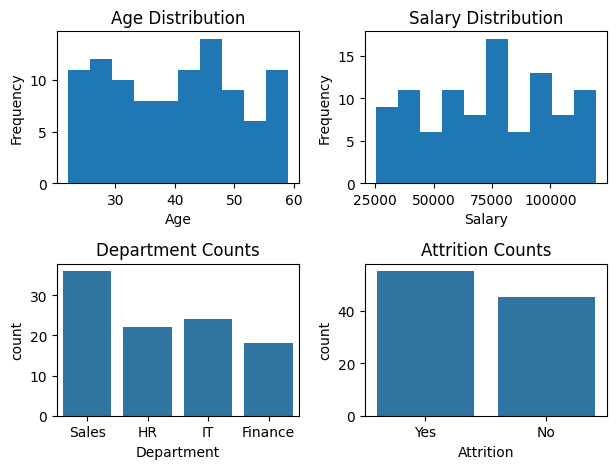

In [161]:
# Age Distribution
plt.subplot(2, 2, 1)
plt.hist(hr_data['Age'], bins=10)
plt.title("Age Distribution")
plt.xlabel('Age')
plt.ylabel('Frequency')

plt.subplot(2, 2, 2)
plt.hist(hr_data['Salary'], bins=10)
plt.title("Salary Distribution")
plt.xlabel('Salary')
plt.ylabel('Frequency')

plt.subplot(2, 2, 3)
sns.countplot(x='Department', data=hr_data)
plt.title("Department Counts")

plt.subplot(2, 2, 4)
sns.countplot(x='Attrition', data=hr_data)
plt.title("Attrition Counts")

plt.tight_layout()
plt.show()

## Bivariate Analysis

Text(0.5, 1.0, 'Experience vs Salary')

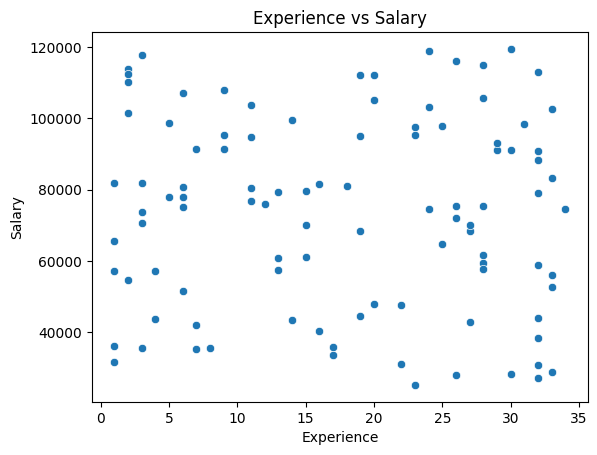

In [162]:
sns.scatterplot(x='Experience', y='Salary', data=hr_data)
plt.title("Experience vs Salary")

Text(0.5, 1.0, 'Age vs Salary')

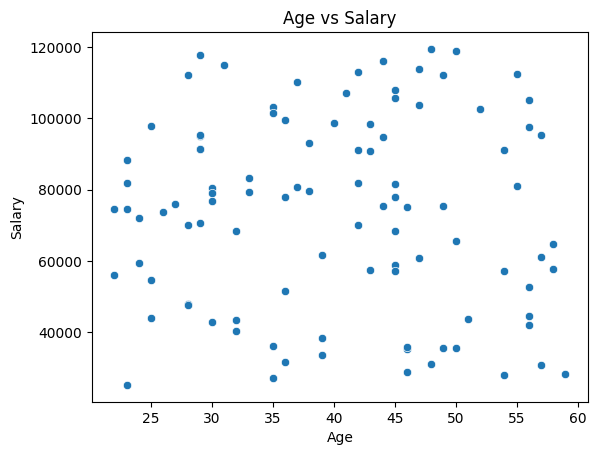

In [163]:
sns.scatterplot(x='Age', y='Salary', data=hr_data)
plt.title('Age vs Salary')

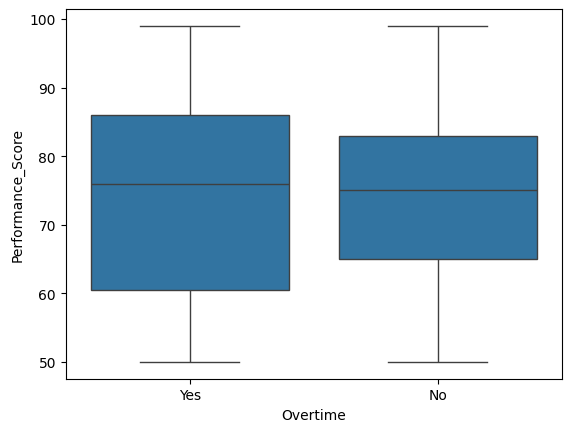

In [164]:
# For Overtime vs Performance
sns.boxplot(x='Overtime', y='Performance_Score', data=df)

plt.show()

## Correlation Analysis

Text(0.5, 1.0, 'Heatmap Correlation of Age, Experience and Salary')

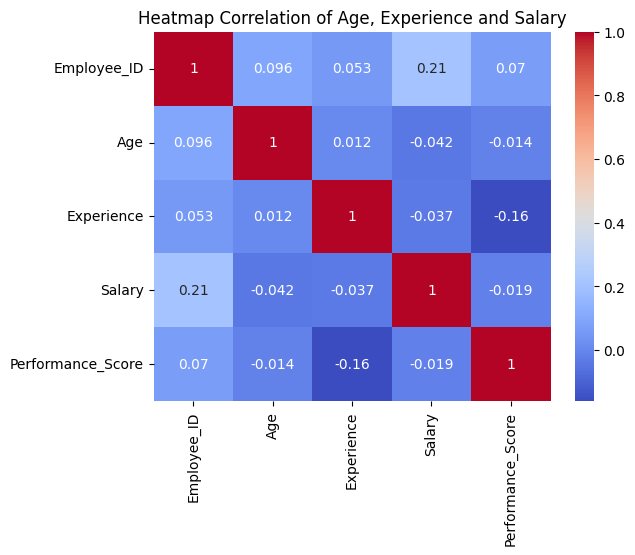

In [165]:
# For Age vs Salary and Exeriance vs Salary we can look at this heatmap
hr_data_corr = hr_data.corr(numeric_only=True)
sns.heatmap(hr_data_corr, annot=True, cmap='coolwarm')
plt.title("Heatmap Correlation of Age, Experience and Salary")

## Outlier Detection

<Axes: ylabel='Age'>

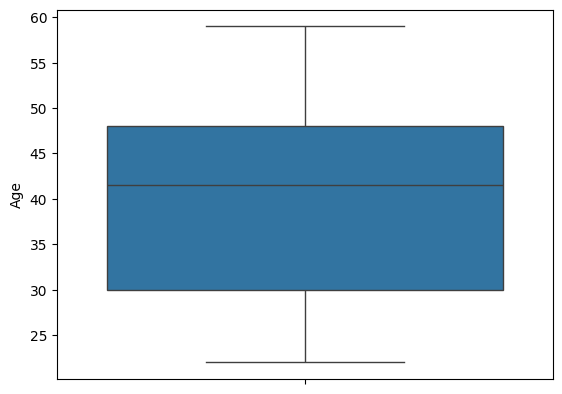

In [166]:
sns.boxplot(hr_data['Age'])

<Axes: ylabel='Experience'>

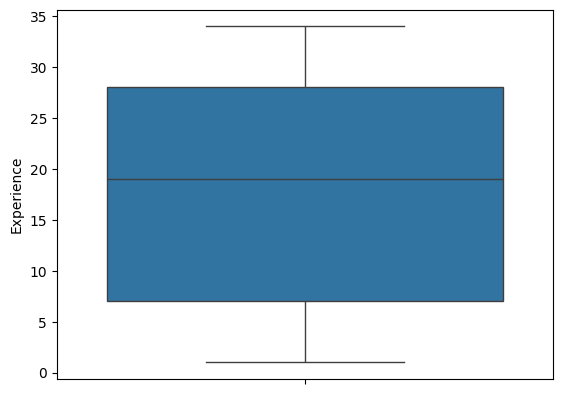

In [167]:
sns.boxplot(hr_data['Experience'])

<Axes: ylabel='Performance_Score'>

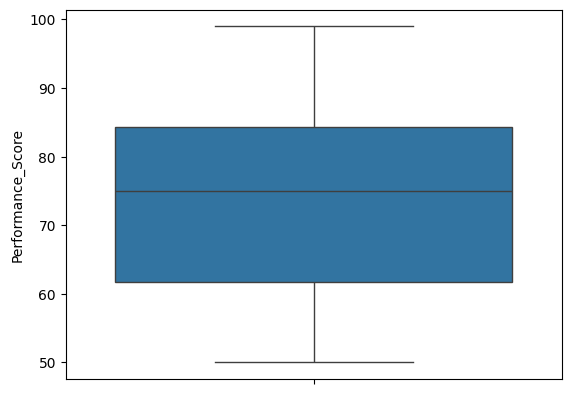

In [168]:
sns.boxplot(hr_data['Performance_Score'])